# Sensitivities as k-space kernels

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/mrtoeplitz/blob/main/examples/coil_kernels.ipynb)

`CoilKernels`: holding a receive array's sensitivities as small centred
k-space kernels and expanding one coil at a time, which is sound exactly when
the maps are band-limited.

In [1]:
try:
    import mrtoeplitz  # noqa: F401
except ImportError:
    %pip install -q "mrtoeplitz[nufft]" matplotlib finufft

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

import mrtoeplitz as mt


def phantom(n=128):
    """A Shepp-Logan phantom on an n x n grid."""
    y, x = np.mgrid[-1 : 1 : n * 1j, -1 : 1 : n * 1j]
    ellipses = [
        # value, centre x, centre y, semi-axis a, semi-axis b, degrees
        (1.0, 0.0, 0.0, 0.69, 0.92, 0),
        (-0.8, 0.0, -0.0184, 0.6624, 0.874, 0),
        (-0.2, 0.22, 0.0, 0.11, 0.31, -18),
        (-0.2, -0.22, 0.0, 0.16, 0.41, 18),
        (0.1, 0.0, 0.35, 0.21, 0.25, 0),
        (0.1, 0.0, 0.1, 0.046, 0.046, 0),
        (0.1, 0.0, -0.1, 0.046, 0.046, 0),
        (0.1, -0.08, -0.605, 0.046, 0.023, 0),
        (0.1, 0.0, -0.606, 0.023, 0.023, 0),
        (0.1, 0.06, -0.605, 0.023, 0.046, 0),
    ]
    image = np.zeros((n, n))
    for value, cx, cy, a, b, degrees in ellipses:
        angle = np.deg2rad(degrees)
        xr = (x - cx) * np.cos(angle) + (y - cy) * np.sin(angle)
        yr = -(x - cx) * np.sin(angle) + (y - cy) * np.cos(angle)
        image[(xr / a) ** 2 + (yr / b) ** 2 <= 1.0] += value
    return image


n, n_coils = 96, 16
image = torch.as_tensor(phantom(n)).to(torch.complex64)

# Two banks of sensitivities that differ in exactly the way that matters.
y, x = np.mgrid[-1 : 1 : n * 1j, -1 : 1 : n * 1j]
angles = np.linspace(0.0, 2 * np.pi, n_coils, endpoint=False)

# Band-limited by construction: built from a small centred k-space kernel,
# which is what an NLINV map is -- its Sobolev weighting is a band limit.
rng = np.random.default_rng(0)
seed = torch.as_tensor(
    rng.normal(size=(n_coils, 12, 12)) + 1j * rng.normal(size=(n_coils, 12, 12))
).to(torch.complex64)
smooth = mt.CoilKernels(seed, (n, n)).materialize()

# Masked, the way an ESPIRiT map is after its eigenvector normalisation: a
# hard edge in the image, whose k-space support is broad.
support = torch.as_tensor((x**2 + y**2) < 0.75**2)
masked = smooth * support
print(f"two banks of {n_coils} maps on a {n}x{n} grid")

two banks of 16 maps on a 96x96 grid


## Maps are the reconstruction

A SENSE normal reads one coil at a time. It never needs the whole bank at
once, but the bank is what gets stored: at 320 cubed with 48 channels, complex
single-precision maps are 12.6 GB, which on most cards *is* the
reconstruction.

A sensitivity is smooth, so its k-space support is small. Holding the kernels
instead and expanding one coil when the apply asks for it trades the bank for
a single map in flight — which the apply already holds. This is riesling's
low-memory mode.

Its one requirement is the whole design: **the map must already be
band-limited**, and `truncation_error` says whether yours is.

In [3]:
kernel_side = 12
band_limited = mt.CoilKernels.from_maps(smooth, (kernel_side, kernel_side))
hard_edged = mt.CoilKernels.from_maps(masked, (kernel_side, kernel_side))

print(band_limited)
print(f"band-limited maps: truncation error {band_limited.truncation_error(smooth):.1e}")
print(f"masked maps:       truncation error {hard_edged.truncation_error(masked):.1e}")
print()
print(f"{band_limited.dense_nbytes / 2**20:.2f} MiB of maps become "
      f"{band_limited.storage_nbytes / 2**20:.3f} MiB of kernels "
      f"({band_limited.compression_ratio:.0f}x)")

CoilKernels(shape=(16, 96, 96), kernel_shape=(12, 12), compression=64.0x)
band-limited maps: truncation error 1.5e-07
masked maps:       truncation error 3.3e-01

1.12 MiB of maps become 0.018 MiB of kernels (64x)


The masked bank loses six orders of magnitude more. That is not a
tuning problem: the `|m| = 1` normalisation an ESPIRiT map carries puts a hard
edge in the image, and a hard edge has broad k-space support. Truncating it is
not band-limiting, it is ringing. For ESPIRiT, keep the calibration kernels
and never form the map; NLINV's maps are band-limited by construction, which
is what makes them the natural pairing.

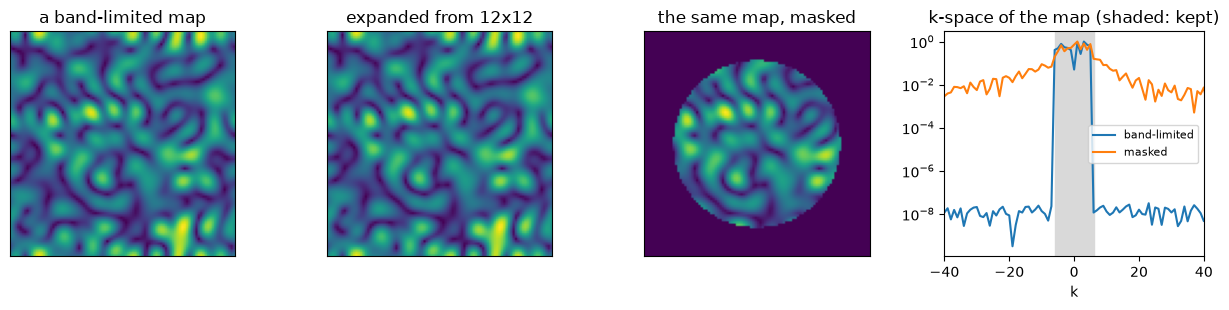

In [4]:
expanded = band_limited.materialize()
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.2))
axes[0].imshow(np.abs(smooth[0].numpy()), cmap="viridis")
axes[0].set_title("a band-limited map")
axes[1].imshow(np.abs(expanded[0].numpy()), cmap="viridis")
axes[1].set_title("expanded from 12x12")
axes[2].imshow(np.abs(masked[0].numpy()), cmap="viridis")
axes[2].set_title("the same map, masked")
for axis in axes[:3]:
    axis.set_xticks([])
    axis.set_yticks([])

spectrum = lambda bank: np.abs(
    np.fft.fftshift(np.fft.fftn(np.fft.ifftshift(bank[0].numpy())))
)
middle = n // 2
for label, bank in (("band-limited", smooth), ("masked", masked)):
    profile = spectrum(bank)[middle]
    axes[3].semilogy(np.arange(n) - middle, profile / profile.max(), label=label)
axes[3].axvspan(-kernel_side // 2, kernel_side // 2, color="0.85", zorder=0)
axes[3].set_xlim(-40, 40)
axes[3].set_title("k-space of the map (shaded: kept)")
axes[3].set_xlabel("k")
axes[3].legend(fontsize=8)
fig.tight_layout()

In [5]:
# Written only when the notebook runs inside a clone, and it is what the
# README shows -- so the figure in the README is always this cell's output.
figures = Path("figures")
if figures.is_dir():
    fig.savefig(figures / "coil_kernels.png", dpi=110, bbox_inches="tight")

## Where it matters

The kernel side is set by how smooth the sensitivity is, not by the image, so
the saving grows with the volume.

In [6]:
# The saving grows with the image, because the kernel does not.
print(f"{'grid':>16}  {'maps':>10}  {'kernels':>10}   ratio")
for side, coils in ((128, 16), (256, 32), (320, 48)):
    dense = coils * side**3 * 8
    kernels = coils * 16**3 * 8
    print(f"{f'{side}^3 x {coils}':>16}  {dense / 2**30:8.2f} GB  "
          f"{kernels / 2**20:8.2f} MB  {dense / kernels:6.0f}x")

            grid        maps     kernels   ratio
      128^3 x 16      0.25 GB      0.50 MB     512x
      256^3 x 32      4.00 GB      1.00 MB    4096x
      320^3 x 48     11.72 GB      1.50 MB    8000x


## In the normal operator

`apply_sense` takes either a tensor or a `CoilKernels`, and nothing else in a
solve changes.

In [7]:
angles = np.linspace(0, np.pi, 96, endpoint=False)
radius = np.linspace(-0.5, 0.5, 192, endpoint=False)
trajectory = np.stack(
    [np.outer(np.cos(angles), radius), np.outer(np.sin(angles), radius)], axis=-1
).astype(np.float32)
kernel = mt.scalar_kernel(trajectory, (n, n))

dense_result = mt.apply_sense(kernel, image[None, None], smooth)
kernel_result = mt.apply_sense(kernel, image[None, None], band_limited)

agreement = float(
    (dense_result - kernel_result).norm() / dense_result.norm()
)
print(f"SENSE normal through maps and through kernels agree to {agreement:.1e}")
print("Every consumer of a bank here reads it one coil batch at a time, so a")
print("CoilKernels stands in for the tensor without anything else changing.")

SENSE normal through maps and through kernels agree to 1.7e-07
Every consumer of a bank here reads it one coil batch at a time, so a
CoilKernels stands in for the tensor without anything else changing.
